## Модель множественной регрессии


Множественная линейная регрессия - это модель, которая вычисляет отношение между двумя или более чем двумя переменными и одной переменной ответа путем подбора уравнения линейной регрессии между ними. Это помогает оценить зависимость или изменение зависимых переменных от изменения независимых переменных. В стандартной множественной линейной регрессии все независимые переменные учитываются одновременно.

### Модуль statsmodel.api для выполнения множественной линейной регрессии в Python

Statsmodels – популярная библиотека на Python, которая позволяет нам оценивать и анализировать различные статистические модели. Он построен на числовых и научных библиотеках, таких как NumPy и SciPy. Некоторые из основных функций этого пакета: Он включает в себя различные модели линейной регрессии, такие как обычный метод наименьших квадратов, обобщенный метод наименьших квадратов, взвешенный метод наименьших квадратов и т. д.

Модуль statsmodel.api в Python снабжен функциями для реализации линейной регрессии. Мы будем использовать функцию OLS(), которая выполняет обычную регрессию по методу наименьших квадратов.

Мы можем либо импортировать набор данных с помощью модуля pandas, либо создать собственные фиктивные данные для выполнения множественной регрессии. Разделяем (раздваиваем) зависимые и независимые переменные, чтобы применить модель линейной регрессии между этими переменными.

Создаем регрессионную модель с помощью функции OLS(). Затем мы передаем независимые и зависимые переменные в эту функцию и подгоняем эту модель с помощью функции fit(). 

In [3]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
y = [1,2,3,4,3,4,5,3,5,5,4,5,4,5,4,5,6,0,6,3,1,3,1] 
x = [[0,2,4,1,5,4,5,9,9,9,3,7,8,8,6,6,5,5,5,6,6,5,5],
     [4,1,2,3,4,5,6,7,5,8,7,8,7,8,7,8,6,8,9,2,1,5,6],
     [4,1,2,5,6,7,8,9,7,8,7,8,7,4,3,1,2,3,4,1,3,9,7]]
def reg_m(y, X):
    ones = np.ones(len(x[0]))
    X = sm.add_constant(np.column_stack((x[0], ones)))
    for ele in x[1:]:
        X = sm.add_constant(np.column_stack((ele, X)))
    results = sm.OLS(y, X).fit()
    return results
print(reg_m(y, X).summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     2.007
Date:                Fri, 25 Apr 2025   Prob (F-statistic):              0.147
Time:                        12:18:05   Log-Likelihood:                -40.810
No. Observations:                  23   AIC:                             89.62
Df Residuals:                      19   BIC:                             94.16
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0287      0.135     -0.213      0.8

Функция ones() возвращает новый массив указанной формы и типа, заполненный единицами.

Параметры:
shape - целое число, список или кортеж целых чисел
Задает размеры необходимого массива.

dtype - тип данных NumPy (необязательный)
Определяет тип данных выходного массива.

order - 'C' или 'F' (необязательный)
Этот параметр определяет в каком порядке массивы должны храниться в памяти: строчном C-стиле или столбчатом стиле Fortran.
Возвращает:
результат - массив NumPy
Массив из единиц, указанной формы, типа и порядка.

Функция summary() позволяет нам распечатать результаты и коэффициенты регрессии. R-Squared (R^2) говорит нам об эффективности регрессии.

### Модуль numpy.linalg.lstsq для выполнения множественной линейной регрессии

In [36]:
import numpy as np

y = [1,2,3,4,3,4,5,3,5,5,4,5,4,5,4,5,6,0,6,3,1,3,1] 
X = [[0,2,4,1,5,4,5,9,9,9,3,7,8,8,6,6,5,5,5,6,6,5,5],
     [4,1,2,3,4,5,6,7,5,8,7,8,7,8,7,8,6,8,9,2,1,5,6],
     [4,1,2,5,6,7,8,9,7,8,7,8,7,4,3,1,2,3,4,1,3,9,7]]
X = np.transpose(X) # транспонировать  входные векторы
X = np.c_[X, np.ones(X.shape[0])]  # массив Х
linreg = np.linalg.lstsq(X, y, rcond=None)[0]
print(linreg)

[ 0.1338682   0.26840334 -0.02874936  1.5122571 ]


## Описание набора данных и постановка задачи

Дан набор данных, котором описаны следующие атрибуты помещения:

#
X1	Относительная компактность	FLOAT
X2	Площадь	FLOAT
X3	Площадь стены	FLOAT
X4	Площадь потолка	FLOAT
X5	Общая высота	FLOAT
X6	Ориентация	INT
X7	Площадь остекления	FLOAT
X8	Распределенная площадь остекления	INT
y1	Нагрузка при обогреве	FLOAT
y2	Нагрузка при охлаждении	FLOAT

В нем X1 ... X8 — характеристики помещения на основании которых будет проводиться анализ, а y1,y2 — значения нагрузки, которые надо спрогнозировать.

### Предварительный анализ данных

Для начала загрузим наши данные и посмотрим на них:

In [1]:
from pandas import read_csv, DataFrame
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score 
from sklearn.model_selection import train_test_split 


KNeighborsRegressor #метод ближайших соседей
SVR #метод опорных векторов
RandomForestRegressor #случайный лес
r2_score #метрика R^2
train_test_split #для разбиения датасета на данные для обучения и тестирования

In [4]:
dataset = pd.read_excel ('ENB2012_data.xlsx')
dataset.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


определим статистические характеристики набора данных, воспользуемся командой describe():


In [5]:
dataset.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


посмотрим не связаны ли между собой какие-либо атрибуты. Сделать это можно рассчитав коэффициенты корреляции для всех столбцов. 

In [6]:
dataset.corr()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
X1,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
X2,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
X3,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
X4,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
X5,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889430,0.895785
X6,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
X7,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269842,0.207505
X8,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Y1,6.222719e-01,-6.581199e-01,4.556714e-01,-8.618281e-01,8.894305e-01,-2.586763e-03,2.698417e-01,8.736846e-02,1.000000,0.975862
Y2,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,1.428960e-02,2.075050e-01,5.052512e-02,0.975862,1.000000


Визуализируем матрицу корреляций и ввиде тепловой карты:

In [7]:
import seaborn as sns

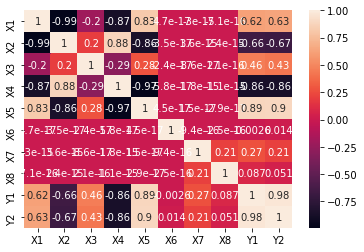

In [8]:
cols = ['X1','X2','X3','X4','X5','X6','X7','X8','Y1','Y2']
hm = sns.heatmap(dataset[cols].corr(),
                 cbar=True,
                 annot=True)

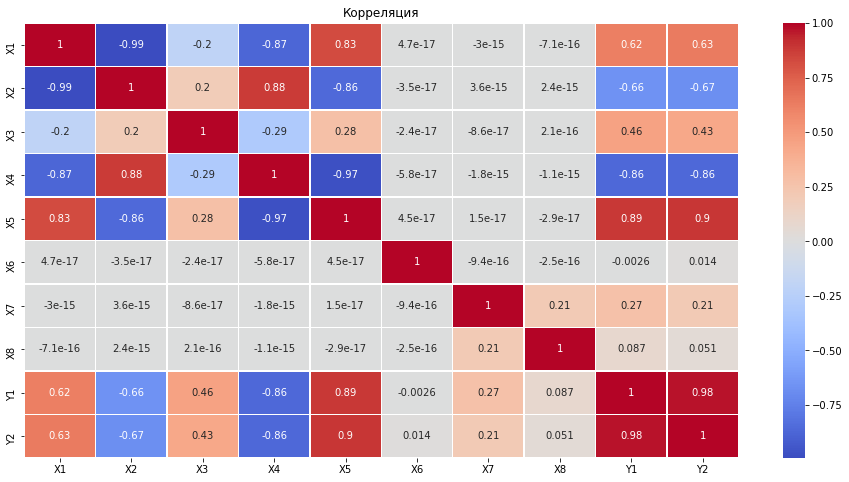

In [9]:
corr_matrix = dataset.corr()
corr_matrix
plt.figure(figsize=(16, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Корреляция")
plt.show()

#
Как можно заметить из нашей матрицы, коррелируют между собой следующие столбы (Значение коэффициента корреляции больше 95%):
y1 --> y2
x1 --> x2
x4 --> x5

выберем, какие столбцы их наших пар мы можем убрать из нашей выборки. Для этого, в каждой паре, выберем столбцы, которые в большей степени оказывают влияние на прогнозные значения Y1 и Y2 и оставим их, а остальные удалим.
Как можно заметить и матрицы с коэффициентами корреляции на y1,y2 больше значения оказывают X2 и X5, нежели X1 и X4, таким образом мы можем последние столбцы мы можем удалить.

Разница в влиянии – минимальна, и трудно сказать почему X2 лучше чем X1, особенно при наличии в модели еще шести переменных. Опять же – просто так взять и выбросить – нельзя. Только проверять. Так, например, если применить метод главных компонент, то в принципе с большой долей вероятности можно избавиться от мультиколлениарности https://yandex.ru/video/preview/11068150494920616817 - метод главных компонент

In [10]:
dataset = dataset.drop(['X1','X4','Y2'],axis=1) 
dataset.head()

,X2,X3,X5,X6,X7,X8,Y1
0,514.5,294.0,7.0,2,0.0,0,15.55
1,514.5,294.0,7.0,3,0.0,0,15.55
2,514.5,294.0,7.0,4,0.0,0,15.55
3,514.5,294.0,7.0,5,0.0,0,15.55
4,563.5,318.5,7.0,2,0.0,0,20.84


Axis: указывает, что столбцы или строки должны быть удалены. Чтобы удалить столбцы, установите для оси значение 1 или «columns». По умолчанию он удаляет строки из DataFrame. Источник: https://pythonpip.ru/pandas/kak-udalit-stolbtsy-v-pandas

Помимо этого, можно заметить, что поля Y1 и Y2 очень тесно коррелируют между собой. Спрогнозируем показатель Y1.

### Выбор модели

Отделим от нашей выборки прогнозные значения:

In [11]:
trg = dataset[['Y1']]
trn = dataset.drop(['Y1'], axis=1)
trg


,Y1
0,15.55
1,15.55
2,15.55
3,15.55
4,20.84
...,...
763,17.88
764,16.54
765,16.44
766,16.48


In [12]:
trn

,X2,X3,X5,X6,X7,X8
0,514.5,294.0,7.0,2,0.0,0
1,514.5,294.0,7.0,3,0.0,0
2,514.5,294.0,7.0,4,0.0,0
3,514.5,294.0,7.0,5,0.0,0
4,563.5,318.5,7.0,2,0.0,0
...,...,...,...,...,...,...
763,784.0,343.0,3.5,5,0.4,5
764,808.5,367.5,3.5,2,0.4,5
765,808.5,367.5,3.5,3,0.4,5
766,808.5,367.5,3.5,4,0.4,5


In [13]:
X_col=dataset[['X2','X3','X5','X6','X7','X8']]
X_col

,X2,X3,X5,X6,X7,X8
0,514.5,294.0,7.0,2,0.0,0
1,514.5,294.0,7.0,3,0.0,0
2,514.5,294.0,7.0,4,0.0,0
3,514.5,294.0,7.0,5,0.0,0
4,563.5,318.5,7.0,2,0.0,0
...,...,...,...,...,...,...
763,784.0,343.0,3.5,5,0.4,5
764,808.5,367.5,3.5,2,0.4,5
765,808.5,367.5,3.5,3,0.4,5
766,808.5,367.5,3.5,4,0.4,5


После обработки данных можно перейти к построению модели. Для построения модели будем использовать следующие методы:
Метод наименьших квадратов
Случайный лес
Логистическую регрессию
Метод опорных векторов
Метод ближайших соседей

 Курс лекций К.В.Воронцова по машинному обучению.  http://www.machinelearning.ru/wiki/index.php?title=Машинное_обучение_(курс_лекций%2C_К.В.Воронцов)

Оценку будем производить с помощью коэффициента детерминации (R-квадрат). 

Коэффициент принимает значение на промежутке [0,1] и чем он ближе к 1 тем сильнее зависимость.

перейдем непосредственно к построению модели. 
Используем LinearRegression(), # метод наименьших квадратов

In [14]:
#Возможно построение моделей следующих видов:
models = [LinearRegression(), # метод наименьших квадратов
	          RandomForestRegressor(n_estimators=100, max_features ='sqrt'), # случайный лес
	          KNeighborsRegressor(n_neighbors=6), # метод ближайших соседей
	          SVR(kernel='linear'), # метод опорных векторов с линейным ядром
	          LogisticRegression() # логистическая регрессия
	          ]
models

[LinearRegression(),
 RandomForestRegressor(max_features='sqrt'),
 KNeighborsRegressor(n_neighbors=6),
 SVR(kernel='linear'),
 LogisticRegression()]

### Тестовая и обучающая выборки

Разобьем наши исходные данные на 2 подвыборки: тестовую и обучающую. 
сделать это можно с помощью функции train_test_split() из пакета scikit-learn

метод train_test_split() используется для создания обучающих и тестовых наборов, переменные функции передаются в методе. размер теста задается как 0,4, что означает, что 40% данных попадает в тестовые наборы, а данные обучающего набора содержат 60% данных. случайное состояние задается для воспроизводимости данных.

In [15]:
Xtrn, Xtest, Ytrn, Ytest = train_test_split(trn, trg, test_size=0.4,random_state=101)
Xtrn

,X2,X3,X5,X6,X7,X8
224,735.0,294.0,3.5,2,0.10,4
764,808.5,367.5,3.5,2,0.40,5
255,612.5,318.5,7.0,5,0.10,5
738,637.0,343.0,7.0,4,0.40,5
392,588.0,294.0,7.0,2,0.25,3
...,...,...,...,...,...,...
75,686.0,245.0,3.5,5,0.10,1
599,661.5,416.5,7.0,5,0.40,2
575,808.5,367.5,3.5,5,0.40,1
337,514.5,294.0,7.0,3,0.25,2


In [16]:
Xtest

,X2,X3,X5,X6,X7,X8
766,808.5,367.5,3.5,4,0.40,5
748,710.5,269.5,3.5,2,0.40,5
42,784.0,343.0,3.5,4,0.00,0
485,563.5,318.5,7.0,3,0.25,5
543,612.5,318.5,7.0,5,0.40,1
...,...,...,...,...,...,...
355,637.0,343.0,7.0,5,0.25,2
489,588.0,294.0,7.0,3,0.25,5
629,563.5,318.5,7.0,3,0.40,3
360,686.0,245.0,3.5,2,0.25,2


Теперь, т. к. нам надо спрогнозировать 2 параметра y1,y2, надо построить регрессию для каждого из них. Кроме этого, для дальнейшего анализа, можно записать полученные результаты во временный DataFrame.

In [17]:
Ytest

,Y1
766,16.48
748,12.43
42,10.77
485,32.31
543,28.65
...,...
355,38.98
489,29.09
629,34.95
360,12.35


Мы разделили наши данные на наборы для обучения и тестирования, и теперь, наконец, пришло время обучить алгоритм.

### Построение модели и обучение алгоритму

In [18]:
from sklearn.linear_model import LinearRegression
# создаем линейную регрессионную модель
model = LinearRegression()

С Scikit-Learn достаточно просто реализовать модели линейной регрессии, тк при этом достаточно импортировать класс LinearRegression, создать его экземпляр и вызвать метод fit() вместе с обучающими данными. 

In [19]:
# Подгоняем модель model к обучающим данным.
#После создания модели она согласуется с данными обучения.
#Модель получает знания о статистике обучающей модели. для подгонки данных используется метод fit().
model.fit(Xtrn,Ytrn)

LinearRegression()

в случае многомерной линейной регрессии регрессионная модель должна найти наиболее оптимальные коэффициенты для всех атрибутов. Посмотрим, какие коэффициенты выбрала наша регрессионная модель

In [20]:
coeff_df = pd.DataFrame(model.coef_.T,X_col.columns, columns=['Значение коэффициента']) 
coeff_df

,Значение коэффициента
X2,0.010000
X3,0.043443
X5,5.256090
X6,-0.055807
X7,20.559079
X8,0.218948


Это означает, что увеличение X2 на единицу приводит к увеличению Y1 на 0,01ед. и ....

### Построение прогноза

После обучения алгоритма можно заниматься прогнозом. Для этого воспользуемся тестовыми данными и посмотрим, насколько точно наш алгоритм предсказывает значения Y1.

В области науки о данных необходимо применять различные модели машинного обучения к наборам данных для обучения данных. Далее выполняется предсказание (прогнозирование) значения для неподготовленных данных.

Для этого может быть использована функция predict().

Функция predict() принимает только один аргумент, который обычно является данными, подлежащими проверке.

Она возвращает метки данных, переданных в качестве аргумента, на основе изученных или обученных данных, полученных из модели.

Таким образом, функция predict() работает поверх обученной модели и использует изученную метку для сопоставления и прогнозирования меток для проверяемых данных.

In [21]:
# выполнение прогноза: подставляем Xtest в обученную модель, находим Ypred и сравниваем с Ytest
#Y_pred сначала определяется как массив numpy, который содержит все предсказанные значения для входных значений в серии X_test.
Y_pred = model.predict(Xtest)
Y_pred= pd.DataFrame(Y_pred)
Y_pred, Ytest

(             0
 0    20.345050
 1    15.219279
 2     9.717334
 3    31.134577
 4    33.721044
 ..         ...
 303  32.165477
 304  30.315240
 305  33.780543
 306  10.169228
 307  15.020245
 
 [308 rows x 1 columns],
         Y1
 766  16.48
 748  12.43
 42   10.77
 485  32.31
 543  28.65
 ..     ...
 355  38.98
 489  29.09
 629  34.95
 360  12.35
 331  17.37
 
 [308 rows x 1 columns])

при сравнении данных видна разница между данными, полученными по обученной модели и Ytest

### Оценим построенную модель с помощью метрик     mean_squared_error и mean_absolute_error 

Модель множественной линейной регрессии оценивается с помощью метрик mean_squared_error и mean_absolute_error. при сравнении со средним значением целевой переменной мы поймем, насколько хорошо наша модель предсказывает. mean_squared_error - это среднее значение суммы остатков. mean_absolute_error - это среднее значение абсолютных ошибок модели. Чем меньше ошибка, тем лучше производительность модели.

средняя абсолютная ошибка (MAE) = это среднее значение суммы абсолютных значений остатков.

среднеквадратичная ошибка (MSE) = это среднее значение суммы квадратов остатков.

Среднеквадратичная ошибка (RMSE) – это квадратный корень из среднего квадрата ошибок:


Среднеквадратичная ошибка (MSE) или среднеквадратичное отклонение (MSD) оценщика — это мера погрешности, которая измеряет среднее значение квадратов ошибок, то есть среднеквадратичную разницу между оценочными значениями и фактическим значением.

MSE — это функция риска, соответствующая ожидаемому значению квадрата потерь при ошибке.

Для непредвзятой оценки MSE — это дисперсия оценки. Как и дисперсия, MSE имеет те же единицы измерения, что и квадрат оцениваемой величины.

По аналогии со стандартным отклонением, извлечение квадратного корня из MSE даёт среднеквадратичную ошибку или среднеквадратичное отклонение (RMSE или RMSD), которое имеет те же единицы измерения, что и оцениваемая величина.

Недостатком использования MSE является то, что если на одном или нескольких неудачных примерах, возможно, содержащих аномальные значения будет допущена значительная ошибка, то возведение в квадрат приведёт к ложному выводу, что вся модель работает плохо. С другой стороны, если модель даст небольшие ошибки на большом числе примеров, то может возникнуть обратный эффект — недооценка слабости модели.

Влияние каждой ошибки на RMSE пропорционально величине квадрата ошибки. Поэтому большие ошибки оказывают непропорционально большое влияние на RMSE. Следовательно, RMSE можно считать чувствительной к аномальным значениям.

In [22]:
from sklearn. metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as msqe

In [23]:
print('средняя абсолютная ошибка:',mae(Ytest, Y_pred)) 
print('средний квадрат ошибок:', msqe(Ytest, Y_pred)) 
print('среднеквадратичная ошибка:', msqe(Ytest, Y_pred)**0.5) 

средняя абсолютная ошибка: 2.080989242868126
средний квадрат ошибок: 8.110568516514437
среднеквадратичная ошибка: 2.8479059880049475


значение среднеквадратичной ошибки составляет 2.85, что немного больше 10% от среднего значения потребления Y1.
Это означает, что наш алгоритм не был очень точным. 

Есть много факторов, которые могли повлиять на эту неточность, некоторые из них: 
1.Требуется больше данных
2.Ошибочные предположения, что данные имеют линейную зависимость,
3.Плохие функции: используемые нами функции могли не иметь достаточно высокой корреляции со значениями, которые мы пытались предсказать.

Источник: 1. https://tonais.ru/library/lineynaya-regressiya-s-pomoschyu-scikit-learn-v-python
2. https://translated.turbopages.org/proxy_u/en-ru.ru.9783c9b2-639ad2c5-fdfdb1e7-74722d776562/https/www.geeksforgeeks.org/multiple-linear-regression-with-scikit-learn/
3. https://www.swe-notes.ru/post/energy_efficiency/